In [1]:

import torch.nn as nn
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
G=1
T=99
estadistica='promedio'
hidden=(10,10) 
path_uniform = f"symmetric/{G}redes{estadistica}/nets_best_by_gid_uniform_{T}.pt"
path_discriminatory = f"symmetric/{G}redes{estadistica}/nets_best_by_gid_pay_as_bid_{T}.pt"

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PolicyNet(nn.Module):
    def __init__(self, input_dim: int, hidden=(10,10), output_dim: int = 1,
                 floor_mode: str = "max", min_bid: float = 1e-6):
        super().__init__()
        layers = []
        d = int(input_dim)
        for h in hidden:
            layers += [nn.Linear(d, int(h)), nn.ReLU()]
            d = int(h)
        layers += [nn.Linear(d, int(output_dim))]
        self.net = nn.Sequential(*layers)

        # parámetros “no entrenables” (puedes cambiar por llamada)
        self.floor_mode = floor_mode
        self.min_bid = float(min_bid)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Devuelve BID factible:
          r(x) = f_theta(x)              (salida latente)
          bid = Gamma_phi(r(x))         (transformación factible)
          bid >= phi  (si x es phi escalar) o bid >= max_h phi_h / mean_h phi_h
        """
        raw = self.net(x).reshape(-1)   # salida latente r(x)

        if x.ndim == 2 and x.shape[1] > 1:
            if self.floor_mode == "max":
                floor = x.max(dim=1).values
            elif self.floor_mode == "mean":
                floor = x.mean(dim=1)
            else:
                raise ValueError("floor_mode must be 'max' or 'mean'")
        else:
            floor = x.reshape(-1)

        floor = torch.clamp_min(floor, 0.0)
        bid = floor + F.softplus(raw) 

        return bid


In [4]:

saved_nets_uniform = torch.load(path_uniform, map_location="cpu")

gid = 1
net_uniform = PolicyNet(
    input_dim=24,
    hidden=hidden,
    output_dim=1,
    floor_mode="mean",   # <- igual que en entrenamiento
    min_bid=1e-6         # <- igual que en entrenamiento
)
net_uniform.load_state_dict(saved_nets_uniform[gid], strict=True)
net_uniform.eval() # importante para modo evaluación




saved_nets_discriminatory = torch.load(path_discriminatory, map_location="cpu")

gid = 1
net_discriminatory = PolicyNet(
    input_dim=24,
    hidden=hidden,
    output_dim=1,
    floor_mode="mean",   # <- igual que en entrenamiento
    min_bid=1e-6         # <- igual que en entrenamiento
)
net_discriminatory.load_state_dict(saved_nets_discriminatory[gid], strict=True)
net_discriminatory.eval() # importante para modo evaluación

PolicyNet(
  (net): Sequential(
    (0): Linear(in_features=24, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=1, bias=True)
  )
)

In [5]:
CSV_PATH = "symmetric/grupos.csv"   # <-- adjust
input = pd.read_csv(CSV_PATH)


In [6]:
input

,id_planta,Fecha,phi,Grupo,precio_d
0,1,2025-04-01,0.083924,1,0.10137
1,2,2025-04-01,0.262222,5,0.28295
2,3,2025-04-01,0.275288,5,0.32637
3,4,2025-04-01,0.260380,5,0.31037
4,5,2025-04-01,0.968472,4,1.02813
...,...,...,...,...,...
4207,32,2025-09-09,0.779362,4,0.90894
4208,33,2025-09-09,1.058581,4,1.11735
4209,34,2025-09-09,0.945489,4,1.01274
4210,35,2025-09-09,0.969786,4,1.18348


In [7]:
import torch

# Suponiendo que tu DataFrame se llama input
def phi_a_tensor_24(phi_val):
    """Recibe un valor escalar y devuelve un tensor (1,24) duplicado"""
    arr = [phi_val] * 24  # lista de 24 valores iguales
    return torch.tensor([arr], dtype=torch.float)  # shape (1,24)
# Lista para guardar resultados

predicciones_uniform = []
predicciones_discriminatory = []
for i, row in input.iterrows():
    x = phi_a_tensor_24(row['phi'])
    y_pred_uniform = net_uniform(x)
    y_pred_discrimininatoty = net_discriminatory(x)
    predicciones_uniform.append(y_pred_uniform.item())  # convertir de tensor a float
    predicciones_discriminatory.append(y_pred_discrimininatoty.item()) 

In [8]:
predicciones_uniform

[0.3660825788974762,
 0.5443803071975708,
 0.5574468970298767,
 0.5425384044647217,
 1.250630497932434,
 0.5722962617874146,
 0.3779996633529663,
 0.36778318881988525,
 0.49948400259017944,
 0.5133653879165649,
 0.5386447906494141,
 0.5463763475418091,
 0.5053389668464661,
 0.6086658835411072,
 0.6478039026260376,
 1.1435574293136597,
 1.1499537229537964,
 0.5087293386459351,
 0.7862173318862915,
 0.7746666669845581,
 1.6388328075408936,
 1.4700677394866943,
 0.5087293386459351,
 0.3188118636608124,
 2.573478937149048,
 0.6274833083152771,
 1.9826321601867676,
 1.8867084980010986,
 1.1131027936935425,
 0.9969357252120972,
 1.034703254699707,
 1.1906551122665405,
 1.695151448249817,
 1.7014496326446533,
 1.3998761177062988,
 1.638993740081787,
 0.35391655564308167,
 1.2287919521331787,
 0.5104658007621765,
 0.5057408809661865,
 1.2551707029342651,
 0.5672792196273804,
 0.3734058141708374,
 0.3664216101169586,
 0.473929762840271,
 0.4767671823501587,
 0.5188760161399841,
 0.5565380454063

In [9]:
predicciones_discriminatory

[0.3660825490951538,
 0.544380247592926,
 0.5574468374252319,
 0.5425383448600769,
 1.250630497932434,
 0.5722962021827698,
 0.3779996335506439,
 0.36778315901756287,
 0.49948397278785706,
 0.5133653879165649,
 0.5386446714401245,
 0.5463762879371643,
 0.5053389072418213,
 0.6086658239364624,
 0.6478038430213928,
 1.1435573101043701,
 1.1499537229537964,
 0.5087293386459351,
 0.7862173318862915,
 0.7746665477752686,
 1.638832688331604,
 1.4700676202774048,
 0.5087293386459351,
 0.31881183385849,
 2.573478937149048,
 0.6274832487106323,
 1.982632040977478,
 1.886708378791809,
 1.1131027936935425,
 0.9969357252120972,
 1.034703254699707,
 1.1906551122665405,
 1.6951513290405273,
 1.7014495134353638,
 1.3998759984970093,
 1.6389936208724976,
 0.3539165258407593,
 1.2287919521331787,
 0.5104658007621765,
 0.5057408809661865,
 1.2551707029342651,
 0.5672792196273804,
 0.373405784368515,
 0.36642158031463623,
 0.4739297330379486,
 0.4767671525478363,
 0.5188759565353394,
 0.5565379858016968,

In [10]:
input['est_uni']=predicciones_uniform
input['est_dis']=predicciones_discriminatory

<Figure size 3600x1500 with 0 Axes>

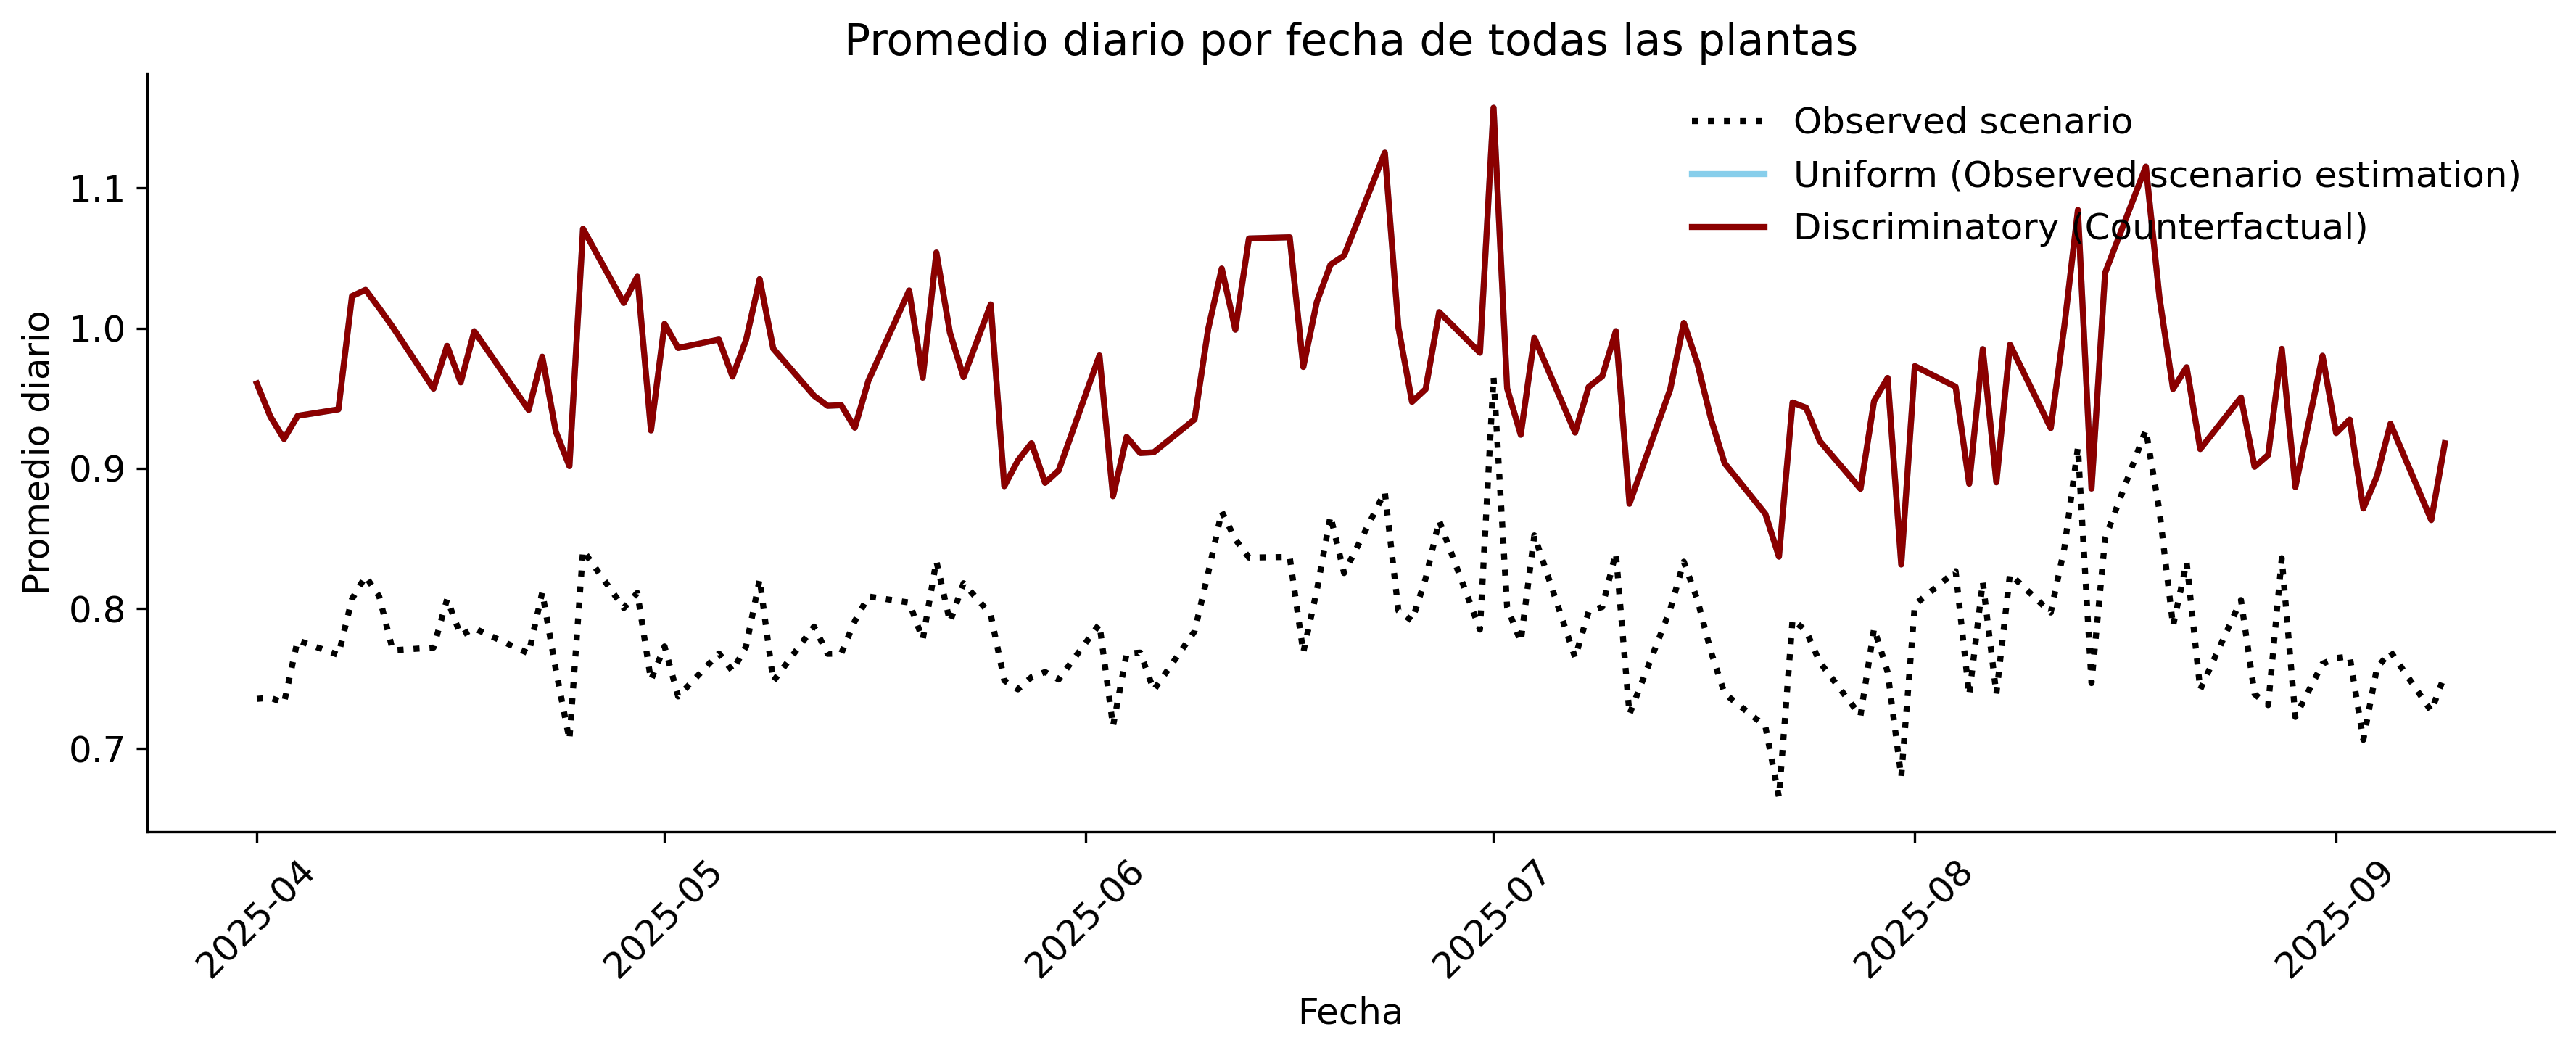

In [11]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

mpl.rcParams.update({
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False
})

# Asegurarse que "Fecha" es datetime
input["Fecha"] = pd.to_datetime(input["Fecha"])

# --- Agrupar por fecha y calcular promedio de todas las plantas ---
df_daily = input.groupby(input["Fecha"].dt.date)[
    ["precio_d", "est_uni", "est_dis"]
].mean().reset_index()

plt.figure(figsize=(12,5), dpi=300)

import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

mpl.rcParams.update({
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False
})

# Asegurarse que "Fecha" es datetime
input["Fecha"] = pd.to_datetime(input["Fecha"])

# Agrupar por fecha y calcular promedio
df_daily = input.groupby(input["Fecha"].dt.date)[
    ["precio_d", "est_uni", "est_dis"]
].mean().reset_index()

plt.figure(figsize=(12,5), dpi=300)

# --- Líneas con colores y estilos ---
plt.plot(df_daily["Fecha"], df_daily["precio_d"], label="Observed scenario",
         color="black", linestyle=":", linewidth=2)        # línea punteada
plt.plot(df_daily["Fecha"], df_daily["est_uni"], label="Uniform (Observed scenario estimation)",
         color="skyblue", linewidth=2)
plt.plot(df_daily["Fecha"], df_daily["est_dis"], label="Discriminatory (Counterfactual)",
         color="darkred", linewidth=2)


plt.xlabel("Fecha")
plt.ylabel("Promedio diario")
plt.title("Promedio diario por fecha de todas las plantas")
plt.legend(frameon=False)
plt.grid(False)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## Equilibrios

In [12]:
import torch
import torch.nn.functional as F

x = phi_a_tensor_24(1.255597)
with torch.no_grad():
    raw = net_uniform.net(x).reshape(-1)
    if x.ndim == 2 and x.shape[1] > 1:
        phi_floor = x.max(dim=1).values if net_uniform.floor_mode == "max" else x.mean(dim=1)
    else:
        phi_floor = x.reshape(-1)
    phi_floor = torch.clamp_min(phi_floor, 0.0)
    bid = phi_floor + F.softplus(raw) + net_uniform.min_bid


print("raw:", raw.item())
print("phi floor:", phi_floor.item())
print("bid:", bid.item())
print("bid-phi_floor:", (bid - phi_floor).item())

raw: -1.1208922863006592
phi floor: 1.2555968761444092
bid: 1.537756323814392
bid-phi_floor: 0.2821594476699829


In [13]:
import torch
import torch.nn.functional as F

x = phi_a_tensor_24(1.255597)
with torch.no_grad():
    raw = net_discriminatory.net(x).reshape(-1)
    inc = F.softplus(raw)
    bid = net_discriminatory(x).reshape(-1)

print("raw:", raw.item())
print("softplus(raw):", inc.item())
print("bid:", bid.item(), "phi:", x.mean().item(), "bid-phi:", (bid - x.mean()).item())

raw: -1.1208924055099487
softplus(raw): 0.28215840458869934
bid: 1.5377552509307861 phi: 1.2555968761444092 bid-phi: 0.28215837478637695


## notas:
en maximo da bien, uniform es mas pequeño que discirminatory bien

## Beneficios

In [14]:
CSV_PATH = "symmetric/df_con_grupos.csv"   # <-- adjust
df = pd.read_csv(CSV_PATH)


In [15]:
df['est_uni']=predicciones_uniform
df['est_dis']=predicciones_discriminatory

In [16]:
df

,CodigoPlanta,available_q,phi,precio_d,Fecha,cluster,id_planta,daily_reman_demand,Grupo,est_uni,est_dis
0,TYP3,"[49.0, 49.0, 49.0, 49.0, 49.0, 49.0, 49.0, 49....",0.083924,0.10137,2025-04-01,10.0,1,"[1029.7, 935.38, 843.32, 771.69, 695.0, 695.0,...",1,0.366083,0.366083
1,TYP2,"[26.0, 26.0, 26.0, 26.0, 26.0, 26.0, 26.0, 26....",0.262222,0.28295,2025-04-01,,2,"[1029.7, 935.38, 843.32, 771.69, 695.0, 695.0,...",5,0.544380,0.544380
2,TSJ2,"[170.0, 170.0, 170.0, 170.0, 170.0, 170.0, 170...",0.275288,0.32637,2025-04-01,10.0,3,"[1029.7, 935.38, 843.32, 771.69, 695.0, 695.0,...",5,0.557447,0.557447
3,TSJ1,"[165.0, 165.0, 165.0, 165.0, 165.0, 165.0, 165...",0.260380,0.31037,2025-04-01,10.0,4,"[1029.7, 935.38, 843.32, 771.69, 695.0, 695.0,...",5,0.542538,0.542538
4,MRL1,"[164.0, 164.0, 164.0, 164.0, 164.0, 164.0, 164...",0.968472,1.02813,2025-04-01,10.0,5,"[1029.7, 935.38, 843.32, 771.69, 695.0, 695.0,...",4,1.250630,1.250630
...,...,...,...,...,...,...,...,...,...,...,...
4207,TRN1,"[80.0, 80.0, 80.0, 80.0, 80.0, 80.0, 80.0, 80....",0.779362,0.90894,2025-09-09,12.0,32,"[1092.15, 1009.76, 945.22, 868.33, 808.01, 733...",4,1.061521,1.061521
4208,TBQ4,"[60.0, 60.0, 60.0, 60.0, 60.0, 60.0, 60.0, 60....",1.058581,1.11735,2025-09-09,12.0,33,"[1092.15, 1009.76, 945.22, 868.33, 808.01, 733...",4,1.340739,1.340739
4209,TBQ3,"[60.0, 60.0, 60.0, 60.0, 60.0, 60.0, 60.080980...",0.945489,1.01274,2025-09-09,12.0,34,"[1092.15, 1009.76, 945.22, 868.33, 808.01, 733...",4,1.227648,1.227648
4210,TVL1,"[241.0, 241.0, 241.0, 241.0, 241.0, 241.0, 241...",0.969786,1.18348,2025-09-09,12.0,35,"[1092.15, 1009.76, 945.22, 868.33, 808.01, 733...",4,1.251944,1.251944


In [17]:
sigma=1e-3
t=0
max(sigma, (sigma * 1e1)* (0.995 ** int(t)))


0.01

In [18]:
df.to_csv(f'symmetric/{G}redes{estadistica}/resultados_Estimaciones_{T}.csv', index=False)